# Checkpoint TTT Evaluation

This notebook loads a checkpoint (humanoidmaze baseline 400k steps seed 0), prepares train and test batches exactly like meta_main, and performs 200 updates while logging and plotting train/test losses.


In [1]:
%load_ext autoreload
%autoreload 2

# ssh -L 8888:eu-lo-g3-048:8888 anmari@eu-login-32

In [2]:
import sys
import yaml
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import gymnasium as gym
import jax
from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset
from utils.env_utils import make_env_and_datasets
from utils.flax_utils import restore_agent
from utils.config import GCTTTConfig, load_config
from utils.data_selection import get_batch_filters, fetch_meta_batch, sample_start_goal_pairs
from agents.gcagent import MetaGCAgent
import tqdm


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 597, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/cluster/home/anmari/gc_ttt/venv/lib/python3.11/site-packages/jax_plugins/xla_

In [186]:
# Configuration
CHECKPOINT_PATH = "/cluster/home/anmari/gc_ttt/exp/pointmaze_stitch/iql_ddpgbc/RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0"  # Update this path
CHECKPOINT_EPOCH = 400000  # 400k steps
SEED = 0
NUM_UPDATES = 200

# You may need to load a config file to get the proper agent config
# For now, we'll try to infer from checkpoint or use defaults
CONFIG_FILE = os.path.dirname(CHECKPOINT_PATH) + "/config.yaml" # Set this if you have a config file
cfg = load_config(CONFIG_FILE)

# Override inner_lr
original_inner_lr = cfg.agent.get("inner_lr")
inner_lr_to_use = 3e-03 # original_inner_lr
cfg.agent["inner_lr"] = inner_lr_to_use
cfg.finetune.inner_lr = inner_lr_to_use

In [187]:
# Set up environment and dataset (exactly like meta_main)
config_agent = cfg.agent
env, train_dataset, val_dataset = make_env_and_datasets(
    cfg.env_name, cfg.data_ratio, frame_stack=config_agent["frame_stack"]
)
env.reset(seed=cfg.seed)
env.action_space.seed(cfg.seed)

dataset_class = {
    "GCDataset": GCDataset,
    "HGCDataset": HGCDataset,
}[config_agent["dataset_class"]]
train_dataset = dataset_class(Dataset.create(**train_dataset), config_agent)
if val_dataset is not None:
    val_dataset = dataset_class(Dataset.create(**val_dataset), config_agent)

print(f"Environment: {cfg.env_name}")
print(f"Dataset class: {config_agent['dataset_class']}")


Environment: pointmaze-medium-stitch-v0
Dataset class: GCDataset


In [188]:
# Initialize agent (exactly like meta_main)
random.seed(cfg.seed)
np.random.seed(cfg.seed)

example_batch = train_dataset.sample(1)
if config_agent["discrete"]:
    # Fill with the maximum action to let the agent know the action space size.
    example_batch["actions"] = np.full_like(
        example_batch["actions"], env.action_space.n - 1
    )

agent_class = agents[config_agent["agent_name"]]
agent: MetaGCAgent
agent = agent_class.create(
    cfg.seed,
    example_batch["observations"],
    example_batch["actions"],
    config_agent,
    cfg.train_steps,
)

print(f"Agent created: {config_agent['agent_name']}")

# Restore agent from checkpoint
print(f"Restoring agent from {CHECKPOINT_PATH} at epoch {CHECKPOINT_EPOCH}")
agent: MetaGCAgent = restore_agent(agent, CHECKPOINT_PATH, CHECKPOINT_EPOCH)
print("Agent restored successfully!")

Agent created: gciql
Restoring agent from /cluster/home/anmari/gc_ttt/exp/pointmaze_stitch/iql_ddpgbc/RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0 at epoch 400000
Restoring learning rate multiplier: 1.0
Restored from /cluster/home/anmari/gc_ttt/exp/pointmaze_stitch/iql_ddpgbc/RANDOM-pointmaze-ddpgbc-PT-1-1-mc0.2-lr0.0003-ilr0.0003/seed0/params_400000.pkl
Agent restored successfully!


In [189]:
# Prepare for updates - get initial task (exactly like meta_main)
is_stitch_dataset = "stitch" in cfg.env_name
train_on_test_goal = True

# Sample start and goal pairs
start_states, goals = sample_start_goal_pairs(
    train_dataset,
    env,
    1,  # meta_batch_size = 1 for single task
    train_on_test_goal,
    is_stitch_dataset=is_stitch_dataset,
    finetune_config=cfg.finetune
)

# Get batch filters
batch_filters_and_max_lens = get_batch_filters(
    train_dataset,
    agent,
    start_states,
    goals,
    cfg.finetune,
    mc_quantile=cfg.finetune.get("mc_quantile_train", None)
)

task_filter = batch_filters_and_max_lens[0][0]
print(f"Task filter has {task_filter.sum()} valid samples")

# Get test batch (exactly like meta_main)
test_batch, test_batch_idx = fetch_meta_batch(
    train_dataset,
    goals[0],
    cfg.finetune,
    batch_filters_and_max_lens[0],
    meta_batch_size=128,  # Same as meta_main
    fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
    verbose=True
)
print(f"Test batch size: {test_batch['observations'].shape[0]}")

Task filter has 220.0 valid samples
Fetching meta batch: filter has 220.0 samples
Test batch size: 128


 ... (more hidden) ...

Fetching meta batch: filter has 128.0 samples


 ... (more hidden) ...


Maze map shape: (8, 8)
Maze unit: 4.0, Offset: (4, 4)


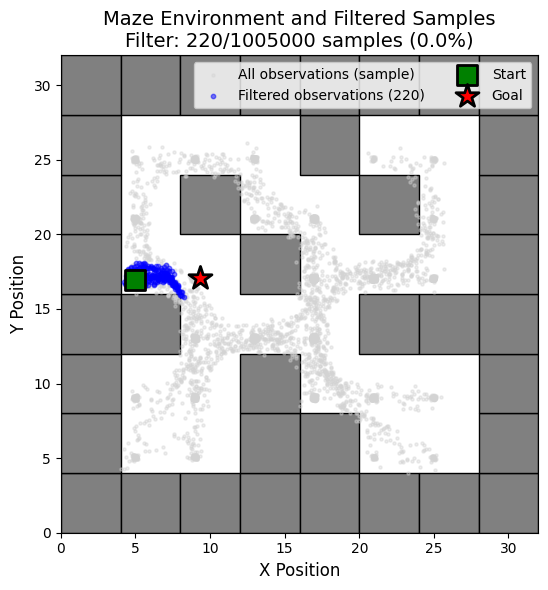

In [190]:
from utils.evaluation import clone_agent
from utils.plotting import plot_maze_and_samples, get_agent_position, draw_maze

actor_only = True # getattr(cfg.finetune, 'actor_only', False)
use_meta_update = False
is_fomaml = False  # Not using FOMAML for this evaluation

# Storage for losses
train_losses = []
test_losses = []
update_steps = []

# Compute initial test loss
_, test_info = agent.total_loss(
    test_batch,
    grad_params=agent.network.params,
    fixed_params=agent.network.params,
    actor_only=actor_only
)
initial_test_loss = test_info.get("total_loss", test_info.get("test/total_loss", 0.0))
test_losses.append(initial_test_loss)

# Compute initial train loss
train_batch, _ = fetch_meta_batch(
    train_dataset,
    goals[0],
    cfg.finetune,
    batch_filters_and_max_lens[0],
    exclude=test_batch_idx,
    fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
)
# Compute initial test loss
_, train_info = agent.total_loss(
    train_batch,
    grad_params=agent.network.params,
    fixed_params=agent.network.params,
    actor_only=actor_only
)
initial_train_loss = train_info.get("total_loss", train_info.get("train/total_loss", 0.0))
train_losses.append(initial_train_loss)
update_steps.append(0)

# print(f"Initial test loss: {initial_test_loss:.6f}")

# Perform 200 updates (exactly like meta_main inner loop)
agent_ft = clone_agent(agent)

for update_step in tqdm.tqdm(range(1, NUM_UPDATES + 1), desc="Updates"):
    # Get train batch (exactly like meta_main)
    train_batch, _ = fetch_meta_batch(
        train_dataset,
        goals[0],
        cfg.finetune,
        batch_filters_and_max_lens[0],
        exclude=test_batch_idx,
        fix_actor_goal=getattr(cfg, 'training_fix_actor_goal', 1.0),
        verbose=update_step == 1  # Only verbose on first step
    )

    if train_batch is None:
        print(f"Warning: No train batch available at step {update_step}")
        break

    # Perform update (exactly like meta_main)
    # For non-meta learning, we use agent.update
    # For meta learning, we use agent.meta_inner_update
    # Since we're doing a simple evaluation, we'll use update
    if use_meta_update:
        agent_ft, batch_info = agent_ft.meta_inner_update(
            0,
            train_batch,
            test_batch,
            is_fomaml=True,
            reset_inner_opt=update_step == 1,
            average_test_gradients=False,
            actor_only=actor_only
        )
    else:
        agent_ft, batch_info = agent_ft.update(
            train_batch,
            actor_only=actor_only
        )

    # Extract train loss from batch_info
    train_loss = batch_info.get("total_loss", batch_info.get("train/total_loss", 0.0))
    train_losses.append(train_loss)


    # Compute test loss
    if use_meta_update:
        params_to_use = agent_ft.network.updated_params_list[0]
    else:
        params_to_use = agent_ft.network.params
    _, test_info = agent_ft.total_loss(
        test_batch,
        grad_params=params_to_use,
        fixed_params=params_to_use,
        actor_only=actor_only,
    )
    test_loss = test_info.get("total_loss", test_info.get("test/total_loss", 0.0))
    test_losses.append(test_loss)
    update_steps.append(update_step)

    # Print progress every 20 steps
    if update_step % 20 == 0:
        pass
        # print(f"Step {update_step}: Train Loss = {train_loss:.6f}, Test Loss = {test_loss:.6f}")
plot_maze_and_samples(train_dataset, batch_filters_and_max_lens[0][0], env, start_states[0], goals[0], cfg)

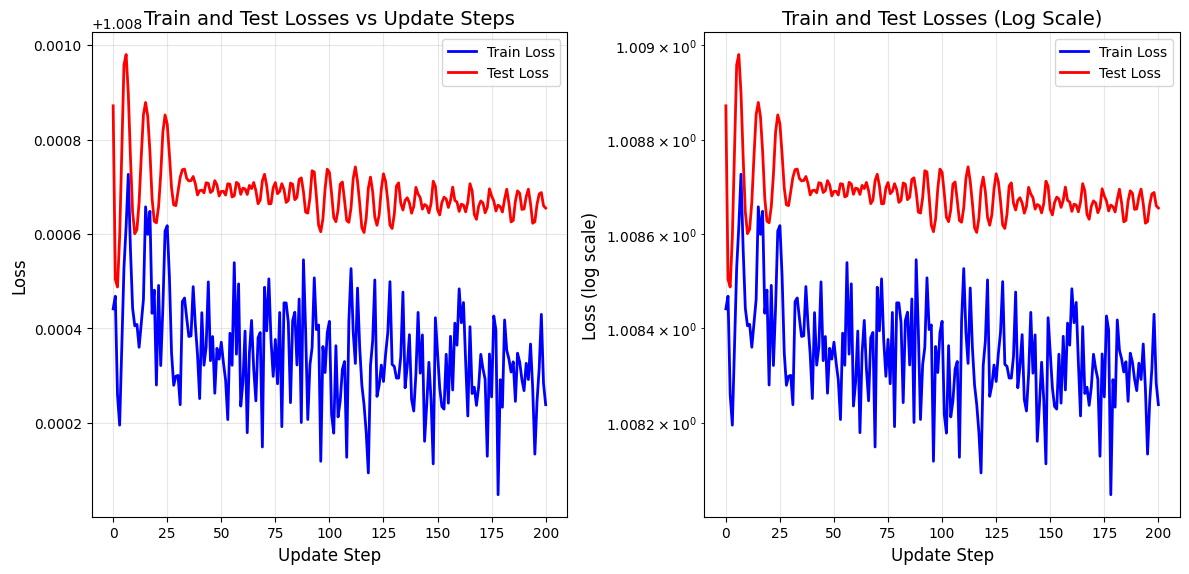


Final Statistics:
  Initial Test Loss: 1.008871
  Final Train Loss: 1.008238
  Final Test Loss: 1.008655
  Test Loss Reduction: 0.02%


In [185]:
# Plot the losses
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(update_steps, train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(update_steps, test_losses, 'r-', label='Test Loss', linewidth=2)
plt.xlabel('Update Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Train and Test Losses vs Update Steps', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(update_steps, train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(update_steps, test_losses, 'r-', label='Test Loss', linewidth=2)
plt.xlabel('Update Step', fontsize=12)
plt.ylabel('Loss (log scale)', fontsize=12)
plt.title('Train and Test Losses (Log Scale)', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nFinal Statistics:")
print(f"  Initial Test Loss: {initial_test_loss:.6f}")
print(f"  Final Train Loss: {train_losses[-1]:.6f}")
print(f"  Final Test Loss: {test_losses[-1]:.6f}")
print(f"  Test Loss Reduction: {((initial_test_loss - test_losses[-1]) / initial_test_loss * 100):.2f}%")